In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("Test_Data.csv") # load the CSV file
print("Columns:", df.columns.tolist())




Columns: ['type', 'ms', 'ax', 'ay', 'az', 'a_mag', 'gx', 'gy', 'gz', 'w_mag', 'qw', 'qx', 'qy', 'qz', 'roll', 'pitch', 'yaw']


In [18]:
# Compute gyroscope magnitude
gyro = df[["gx","gy","gz"]].values.astype(float)
gyro_mag = np.linalg.norm(gyro, axis=1)

# Threshold for motion detection (tune if needed)
threshold = 0.3   # rad/s

# Find swing start and end
motion_indices = np.where(gyro_mag > threshold)[0]

if len(motion_indices) == 0:
    raise ValueError("No swing detected — try lowering threshold.")

start_idx = motion_indices[0]
end_idx   = motion_indices[-1]

print("Swing starts at row:", start_idx)
print("Swing ends at row:", end_idx)

# Keep only swing portion
df = df.iloc[start_idx:end_idx+1].reset_index(drop=True)


Swing starts at row: 4
Swing ends at row: 352


In [19]:
def quat_to_rotmat(qw, qx, qy, qz):
    """Return 3x3 rotation matrix from quaternion (w, x, y, z)."""
    n = np.sqrt(qw*qw + qx*qx + qy*qy + qz*qz)
    if n == 0:
        return np.eye(3)
    qw, qx, qy, qz = qw/n, qx/n, qy/n, qz/n

    ww, xx, yy, zz = qw*qw, qx*qx, qy*qy, qz*qz
    wx, wy, wz = qw*qx, qw*qy, qw*qz
    xy, xz, yz = qx*qy, qx*qz, qy*qz

    R = np.array([
        [ww + xx - yy - zz,     2*(xy - wz),         2*(xz + wy)],
        [2*(xy + wz),           ww - xx + yy - zz,   2*(yz - wx)],
        [2*(xz - wy),           2*(yz + wx),         ww - xx - yy + zz]
    ])
    return R

g_world = np.array([0.0, 0.0, 9.81])

acc_world = np.zeros_like(acc_s)

for i in range(N):
    qw, qx, qy, qz = q[i]
    R = quat_to_rotmat(qw, qx, qy, qz)  # body → world
    a_s = acc_s[i]

    # Sensor-frame accel → world-frame accel (still includes gravity)
    a_w = R @ a_s

    # Remove gravity in world frame
    acc_world[i] = a_w - g_world

# Bias correction using early "rest" samples
rest_N = min(200, N)
bias = acc_world[:rest_N].mean(axis=0)
acc_world_bc = acc_world - bias


In [20]:
vel = np.zeros_like(acc_world_bc)
for i in range(1, N):
    vel[i] = vel[i-1] + 0.5 * (acc_world_bc[i] + acc_world_bc[i-1]) * dt[i]

# Drift correction: force velocity to end near zero
alpha = np.linspace(0.0, 1.0, N)[:, None]
vel_drift = alpha * vel[-1]          # linear drift from 0 → vel_end
vel_corr = vel - vel_drift


In [21]:
pos = np.zeros_like(vel_corr)
for i in range(1, N):
    pos[i] = pos[i-1] + 0.5 * (vel_corr[i] + vel_corr[i-1]) * dt[i]

# Optional: start at origin
pos = pos - pos[0]


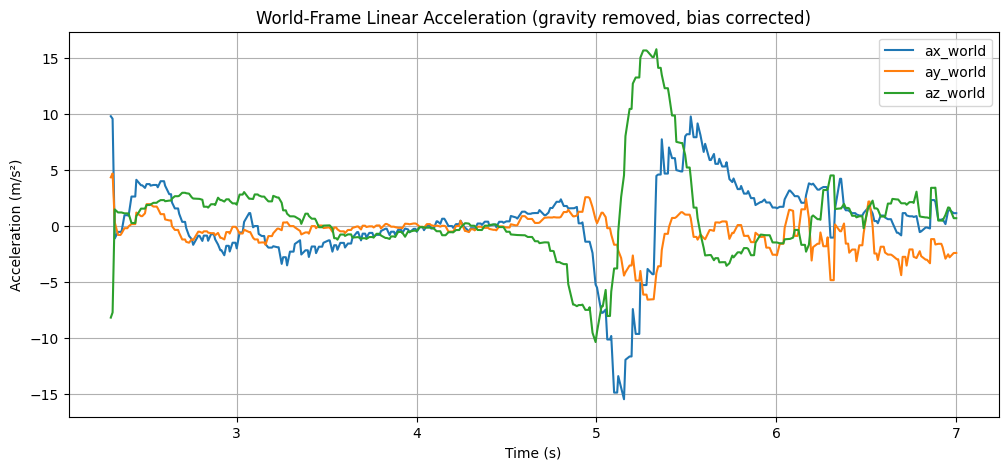

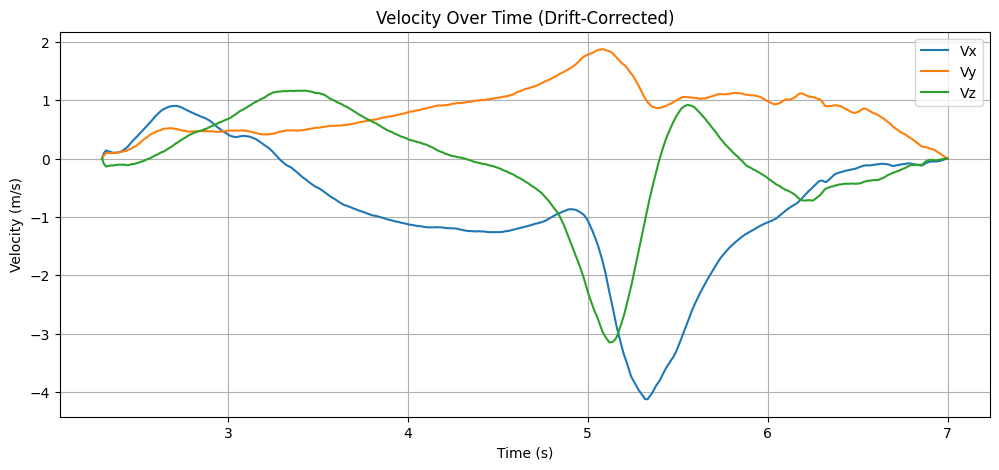

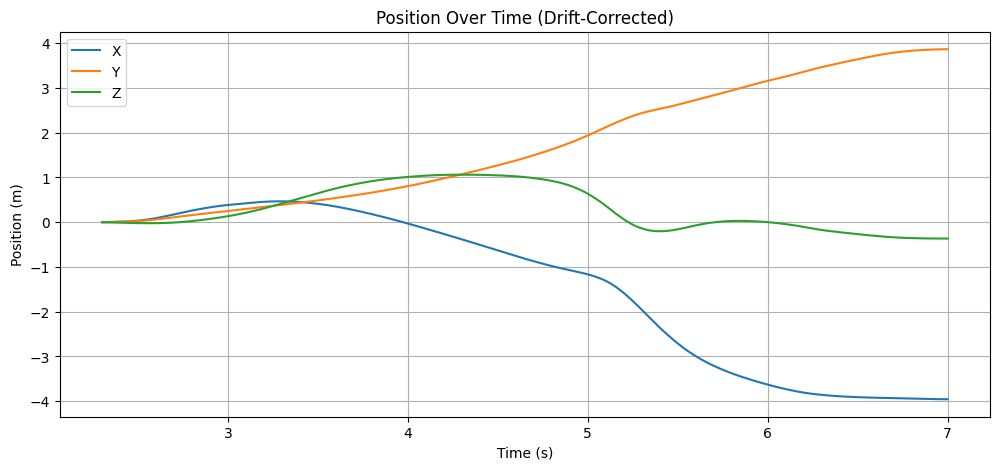

In [22]:
# World-frame, gravity-removed, bias-corrected acceleration
plt.figure(figsize=(12,5))
plt.plot(t, acc_world_bc[:,0], label="ax_world")
plt.plot(t, acc_world_bc[:,1], label="ay_world")
plt.plot(t, acc_world_bc[:,2], label="az_world")
plt.title("World-Frame Linear Acceleration (gravity removed, bias corrected)")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.legend(); plt.grid(True)
plt.show()

# Drift-corrected velocity
plt.figure(figsize=(12,5))
plt.plot(t, vel_corr[:,0], label="Vx")
plt.plot(t, vel_corr[:,1], label="Vy")
plt.plot(t, vel_corr[:,2], label="Vz")
plt.title("Velocity Over Time (Drift-Corrected)")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend(); plt.grid(True)
plt.show()

# Drift-corrected position
plt.figure(figsize=(12,5))
plt.plot(t, pos[:,0], label="X")
plt.plot(t, pos[:,1], label="Y")
plt.plot(t, pos[:,2], label="Z")
plt.title("Position Over Time (Drift-Corrected)")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend(); plt.grid(True)
plt.show()


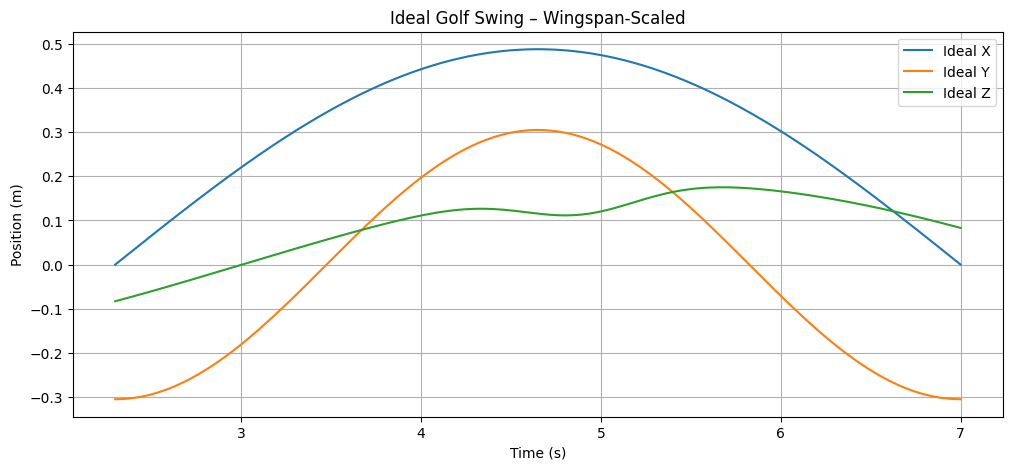

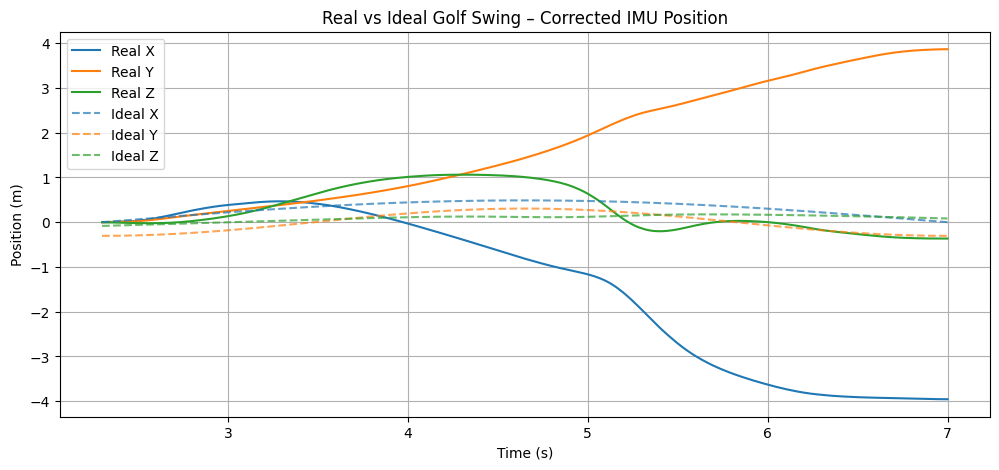

In [23]:
# Time normalization for ideal swing
t_norm = (t - t.min()) / (t.max() - t.min())

# Ideal swing model (normalized)
X = 0.4 * np.sin(np.pi * t_norm)
Y = 0.25 * np.sin(2 * np.pi * t_norm - np.pi/2)
Z = 0.15 * np.sin(np.pi * (t_norm - 0.15)) - 0.05 * np.exp(-((t_norm-0.55)**2)/0.01)

ideal_pos = np.vstack([X, Y, Z]).T

# Scale ideal swing using your wingspan
height_m = 1.778  # 5'10"
wingspan_m = height_m
arm_radius = 0.33 * wingspan_m

ideal_radius_current = np.max(np.linalg.norm(ideal_pos, axis=1))
scale_factor = arm_radius / ideal_radius_current
ideal_scaled = ideal_pos * scale_factor

# Ideal swing alone
plt.figure(figsize=(12,5))
plt.plot(t, ideal_scaled[:,0], label="Ideal X")
plt.plot(t, ideal_scaled[:,1], label="Ideal Y")
plt.plot(t, ideal_scaled[:,2], label="Ideal Z")
plt.title("Ideal Golf Swing – Wingspan-Scaled")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend(); plt.grid(True)
plt.show()

# Real vs Ideal overlay
plt.figure(figsize=(12,5))
plt.plot(t, pos[:,0], label="Real X", color="tab:blue")
plt.plot(t, pos[:,1], label="Real Y", color="tab:orange")
plt.plot(t, pos[:,2], label="Real Z", color="tab:green")

plt.plot(t, ideal_scaled[:,0], "--", label="Ideal X", color="tab:blue", alpha=0.7)
plt.plot(t, ideal_scaled[:,1], "--", label="Ideal Y", color="tab:orange", alpha=0.7)
plt.plot(t, ideal_scaled[:,2], "--", label="Ideal Z", color="tab:green", alpha=0.7)

plt.title("Real vs Ideal Golf Swing – Corrected IMU Position")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend(); plt.grid(True)
plt.show()
